## Detecting Spam Emails Using Tensorflow in Python

#### Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
nltk.download("stopwords")

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import  warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### Reading the Dataset

In [2]:
data = pd.read_csv(r'C:\users\hp\downloads\spam_ham_dataset.csv')
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\nth...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\n( see a...",0
2,3624,ham,"Subject: neon retreat\nho ho ho , we ' re arou...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\nthis deal is to ...,0


#### Shape of the Dataset

In [3]:
data.shape

(5171, 4)

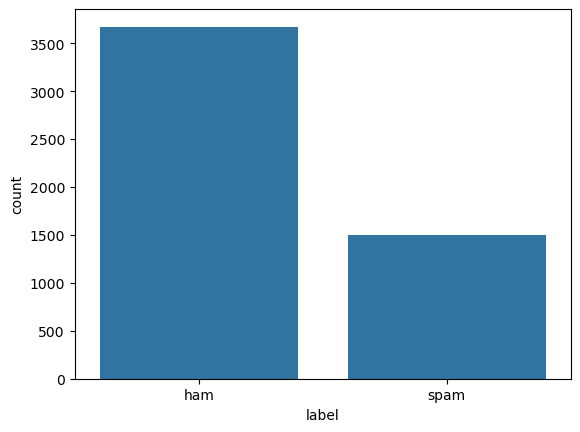

In [4]:
sns.countplot(x ="label",data=data)
plt.show()

In [ ]:
#### Balanced the Dataset of ham and spam emails

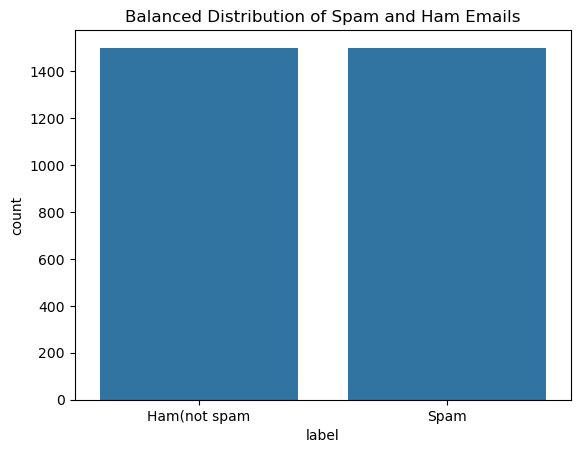

In [5]:
ham_msg = data[data['label']=='ham']
spam_msg = data[data['label']=='spam']
## Downsample Ham emails to match the number of spams emails
ham_msg_balanced = ham_msg.sample(n=len(spam_msg), random_state=42)

## Combine Balanced data
balanced_data = pd.concat([ham_msg_balanced,spam_msg]).reset_index(drop=True)

## Visualize the balanced dataset 
sns.countplot(x="label", data=balanced_data)
plt.title("Balanced Distribution of Spam and Ham Emails")
plt.xticks(ticks=[0,1],labels=["Ham(not spam","Spam"])
plt.show()

#### Data Cleaning Process

In [6]:
balanced_data['text'] = balanced_data['text'].str.replace("Subject",'')
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,: conoco - big cowboy\ndarren :\ni ' m not sur...,0
1,2982,ham,: feb 01 prod : sale to teco gas processing\ns...,0
2,2711,ham,": california energy crisis\ncalifornia  , s p...",0
3,3116,ham,: re : nom / actual volume for april 23 rd\nwe...,0
4,1314,ham,: eastrans nomination changes effective 8 / 2 ...,0


#### Punctuations Removing

In [7]:
punctuations_list = string.punctuation
def remove_punctuations(text):
    temp = str.maketrans('','',punctuations_list)
    return text.translate(temp)

balanced_data['text'] = balanced_data['text'].apply(lambda x:remove_punctuations(x))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy\ndarren \ni m not sure if...,0
1,2982,ham,feb 01 prod sale to teco gas processing\nsal...,0
2,2711,ham,california energy crisis\ncalifornia  s pow...,0
3,3116,ham,re nom actual volume for april 23 rd\nwe ag...,0
4,1314,ham,eastrans nomination changes effective 8 2 0...,0


#### Removing Stopwords

In [8]:
def remove_stopwords(text):
    stop_words = stopwords.words('english')

    imp_words = []

    # Storing the important words
    for word in str(text).split():
        word = word.lower()

        if word not in stop_words:
            imp_words.append(word)

    output = " ".join(imp_words)

    return output


balanced_data['text'] = balanced_data['text'].apply(lambda text: remove_stopwords(text))
balanced_data.head()

,Unnamed: 0,label,text,label_num
0,3444,ham,conoco big cowboy darren sure help know else a...,0
1,2982,ham,feb 01 prod sale teco gas processing sale deal...,0
2,2711,ham,california energy crisis california  power cr...,0
3,3116,ham,nom actual volume april 23 rd agree eileen pon...,0
4,1314,ham,eastrans nomination changes effective 8 2 00 p...,0


#### Using WordCloud we can Distribute of Non_spam and Ham Emails

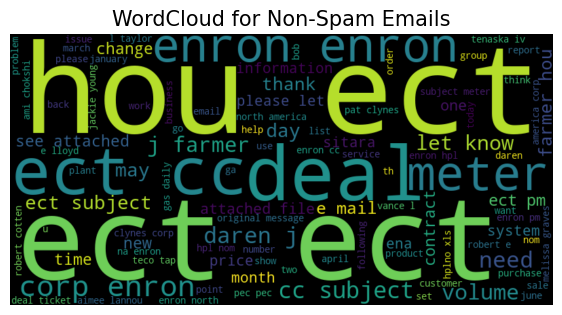

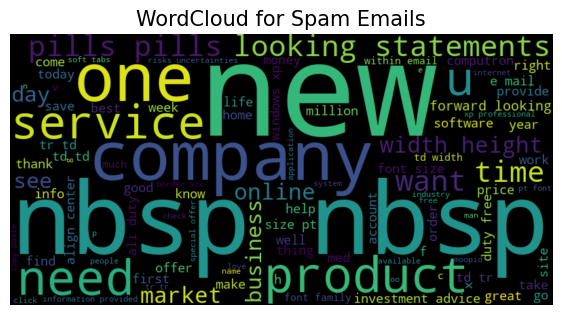

In [9]:
def plot_word_cloud(data, typ):
    email_corpus = " ".join(data['text'])
    wc = WordCloud(background_color='black', max_words=100, width=800, height=400).generate(email_corpus)
    plt.figure(figsize=(7, 7))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'WordCloud for {typ} Emails', fontsize=15)
    plt.axis('off')
    plt.show()

plot_word_cloud(balanced_data[balanced_data['label'] == 'ham'], typ='Non-Spam')
plot_word_cloud(balanced_data[balanced_data['label'] == 'spam'], typ='Spam')

#### Splitting the Training and Testing Dataset and padding using Keras Preprocessing

In [10]:
train_X, test_X, train_Y, test_Y = train_test_split(
    balanced_data['text'],
    balanced_data['label_num'],
    test_size=0.2,
    random_state=42
)

tokenizer = Tokenizer()
tokenizer.fit_on_texts(train_X)

train_sequences = tokenizer.texts_to_sequences(train_X)
test_sequences = tokenizer.texts_to_sequences(test_X)

max_len = 100

train_sequences = pad_sequences(train_sequences, maxlen=max_len, padding='post', truncating='post')
test_sequences = pad_sequences(test_sequences, maxlen=max_len, padding='post', truncating='post')


#### Model Training, Compile and Fitting the Dataset

In [11]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=32, input_length=max_len),
    tf.keras.layers.LSTM(16),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer
])

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)


history = model.fit(
    train_sequences, train_Y,
    validation_data=(test_sequences, test_Y),
    epochs=10,
    batch_size=32
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - accuracy: 0.5588 - loss: 0.6876 - val_accuracy: 0.6567 - val_loss: 0.6366
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.9291 - loss: 0.2666 - val_accuracy: 0.9617 - val_loss: 0.1490
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9537 - loss: 0.1945 - val_accuracy: 0.9617 - val_loss: 0.1686
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.9796 - loss: 0.1067 - val_accuracy: 0.9633 - val_loss: 0.1755
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9862 - loss: 0.0751 - val_accuracy: 0.9650 - val_loss: 0.1616
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.9879 - loss: 0.0662 - val_accuracy: 0.9650 - val_loss: 0.1633
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.9867 - loss: 0.0706 - val_accuracy: 0.9667 - val_loss: 0.1556
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.8374 - loss: 0.4409 - val_accuracy: 0.9700 - 

#### Summary using trained model

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 100, 32)             │       1,274,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 16)                  │           3,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │             544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,835,877 (14.63 MB)

 Trainable params: 1,278,625 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,557,252 (9.76 MB)

#### Finding the Test Loss and Test Accuracy

In [13]:
test_loss, test_accuracy = model.evaluate(test_sequences, test_Y)
print('Test Loss :',test_loss)
print('Test Accuracy :',test_accuracy)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9817 - loss: 0.0878
Test Loss : 0.08776989579200745
Test Accuracy : 0.9816666841506958


#### Creating line chart Actual Accuracy and validation accuracy 

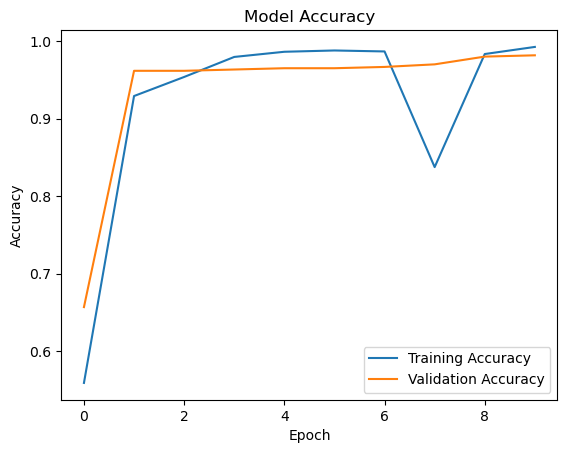

In [14]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()